In [1]:
import pandas as pd

df= pd.read_csv('post natal data.csv')
print(df.shape)
df.head()




(1503, 11)


,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Timestamp                                  1503 non-null   object
 1   Age                                        1503 non-null   object
 2   Feeling sad or Tearful                     1503 non-null   object
 3   Irritable towards baby & partner           1497 non-null   object
 4   Trouble sleeping at night                  1503 non-null   object
 5   Problems concentrating or making decision  1491 non-null   object
 6   Overeating or loss of appetite             1503 non-null   object
 7   Feeling anxious                            1503 non-null   object
 8   Feeling of guilt                           1494 non-null   object
 9   Problems of bonding with baby              1503 non-null   object
 10  Suicide attempt                     

In [3]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


Timestamp:
['6/14/2022 20:02' '6/14/2022 20:03' '6/14/2022 20:04' '6/14/2022 20:05'
 '6/14/2022 20:06' '6/14/2022 20:07' '6/14/2022 20:11' '6/14/2022 22:04'
 '6/14/2022 22:05' '6/14/2022 22:06' '6/14/2022 22:07' '6/14/2022 22:08'
 '6/14/2022 22:09' '6/14/2022 22:10' '6/14/2022 22:15' '6/14/2022 22:16'
 '6/14/2022 22:17' '6/14/2022 22:18' '6/14/2022 23:25' '6/14/2022 23:26'
 '6/14/2022 23:27' '6/14/2022 23:28' '6/14/2022 23:29' '6/14/2022 23:30'
 '6/14/2022 23:31' '6/14/2022 23:32' '6/14/2022 23:33' '6/14/2022 23:34'
 '6/14/2022 23:35' '6/14/2022 23:36' '6/14/2022 23:37' '6/14/2022 23:38'
 '6/14/2022 23:39' '6/14/2022 23:40' '6/14/2022 23:41' '6/14/2022 23:42'
 '6/14/2022 23:43' '6/14/2022 23:44' '6/14/2022 23:45' '6/14/2022 23:46'
 '6/14/2022 23:47' '6/14/2022 23:48' '6/14/2022 23:49' '6/14/2022 23:50'
 '6/14/2022 23:52' '6/14/2022 23:53' '6/15/2022 0:02' '6/15/2022 0:06'
 '6/15/2022 0:07' '6/15/2022 0:10' '6/15/2022 0:11' '6/15/2022 0:12'
 '6/15/2022 0:13' '6/15/2022 0:14' '6/15/2022

In [4]:
df = df.drop(columns=['Timestamp'])

In [5]:
df['Overeating or loss of appetite']=df['Overeating or loss of appetite'].replace('Not at all', 'No')

In [6]:
#encoding
encoding = {
    'Feeling sad or Tearful': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Irritable towards baby & partner': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Trouble sleeping at night': {'No': 0, 'Yes': 1, 'Two or more days a week': 2},
    'Problems concentrating or making decision': {'No': 0, 'Often': 1, 'Yes': 2},
    'Overeating or loss of appetite': {'No': 0, 'Yes': 1},
    'Feeling anxious': {'No': 0, 'Yes': 1},
    'Feeling of guilt': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Problems of bonding with baby': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Suicide attempt': {'No': 0, 'Not interested to say': 1, 'Yes': 1}

}
#apply encoding
#"For each column and its encoding rules, go through every value in 
#that column and replace the text with the corresponding number."
for col, mapping in encoding.items():
    df[col]=df[col].map(mapping)
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,2,2.0,2,2.0,1,1,0.0,2,1
1,40-45,2,0.0,0,2.0,1,0,2.0,2,0
2,35-40,2,0.0,1,2.0,1,1,0.0,1,0
3,35-40,2,2.0,1,2.0,0,1,1.0,0,0
4,40-45,2,0.0,2,2.0,0,1,0.0,2,0


In [7]:
print(df.columns.tolist())

['Age', 'Feeling sad or Tearful', 'Irritable towards baby & partner', 'Trouble sleeping at night', 'Problems concentrating or making decision', 'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt', 'Problems of bonding with baby', 'Suicide attempt']


In [8]:
print(df.isnull().sum())

Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64


In [9]:
#filling missing values with mode
for col in df.columns:
    df[col]=df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())

Age                                          0
Feeling sad or Tearful                       0
Irritable towards baby & partner             0
Trouble sleeping at night                    0
Problems concentrating or making decision    0
Overeating or loss of appetite               0
Feeling anxious                              0
Feeling of guilt                             0
Problems of bonding with baby                0
Suicide attempt                              0
dtype: int64


In [10]:
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,2,2.0,2,2.0,1,1,0.0,2,1
1,40-45,2,0.0,0,2.0,1,0,2.0,2,0
2,35-40,2,0.0,1,2.0,1,1,0.0,1,0
3,35-40,2,2.0,1,2.0,0,1,1.0,0,0
4,40-45,2,0.0,2,2.0,0,1,0.0,2,0


In [11]:
df = df.astype({'Irritable towards baby & partner': 'int',
                'Problems concentrating or making decision': 'int',
                'Feeling of guilt': 'int'})
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,2,2,2,2,1,1,0,2,1
1,40-45,2,0,0,2,1,0,2,2,0
2,35-40,2,0,1,2,1,1,0,1,0
3,35-40,2,2,1,2,0,1,1,0,0
4,40-45,2,0,2,2,0,1,0,2,0


In [12]:
# Extract midpoint from age range
df['Age'] = df['Age'].apply(lambda x: (int(x.split('-')[0]) + int(x.split('-')[1])) / 2)

df['Age'].unique()

array([37.5, 42.5, 32.5, 47.5, 27.5])

df.head()

The real EPDS has 10 questions, each scored 0-3. Maximum score = 30.
A score of 10 or above indicates possible PPD.
Your dataset has 9 symptom columns scored 0-2. Maximum score = 18.
So we scale the threshold proportionally:

Original: 10 out of 30 = 33%
Your data: 33% of 18 = ~6

So threshold = 6 for your dataset.


In [13]:
symptom_cols = ['Feeling sad or Tearful', 'Irritable towards baby & partner',
                'Trouble sleeping at night', 'Problems concentrating or making decision',
                'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
                'Problems of bonding with baby', 'Suicide attempt']
#calculate total score
df['total_score'] = df[symptom_cols].sum(axis=1)

#create target variable
df['PPD']=(df['total_score']>=6).astype(int)

#check distribution
print(df['PPD'].value_counts())



1    1237
0     266
Name: PPD, dtype: int64


In [14]:
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt,total_score,PPD
0,37.5,2,2,2,2,1,1,0,2,1,13,1
1,42.5,2,0,0,2,1,0,2,2,0,9,1
2,37.5,2,0,1,2,1,1,0,1,0,8,1
3,37.5,2,2,1,2,0,1,1,0,0,9,1
4,42.5,2,0,2,2,0,1,0,2,0,9,1


#ordinal and nominal data
#vectorization:pandas.isnull():pandas works on the entire column at once instead of looping row by row

Recall is our evaluation metric, since we need to find in this case, out of how many positive cases of ppd, how many of them our model catches and predicted positive

Recall
Out of everyone who actually had PPD, how many did you catch?
TP / (TP + FN)

In [15]:
#"Save my clean dataframe as a CSV file called ppd_clean.csv, without the row numbers
df.to_csv('ppd_clean.csv',index=False)
#this is the preprocessed cleaned dataset

In [16]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['PPD', 'total_score'])
y=df['PPD']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)
print("PPD distribution in training:", y_train.value_counts())
print("PPD distribution in test:", y_test.value_counts())

Training size: (1202, 10)
Test size: (301, 10)
PPD distribution in training: 1    986
0    216
Name: PPD, dtype: int64
PPD distribution in test: 1    251
0     50
Name: PPD, dtype: int64


In [17]:
print(X.columns.tolist())

['Age', 'Feeling sad or Tearful', 'Irritable towards baby & partner', 'Trouble sleeping at night', 'Problems concentrating or making decision', 'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt', 'Problems of bonding with baby', 'Suicide attempt']


In [18]:
from sklearn.linear_model import LogisticRegression


lr_model= LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print(y_pred)

[1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1
 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0
 1 1 1 1 1]


Imagine you're walking downhill blindfolded trying to find the lowest point.
Two reasons you might not reach the bottom:
Reason 1 — Not enough steps
You're still moving downhill but ran out of steps. Solution → give more steps (increase max_iter). This is your current situation.
Reason 2 — The hill is too steep and uneven
Your steps are too big — you keep overshooting the lowest point and jumping to the other side. More steps won't help here. Solution → scale your data.
What is scaling?
Right now your features have very different ranges:

Age → 27.5 to 47.5
Symptom columns → 0, 1, 2

Age values are much larger than symptom values. This makes the optimization landscape uneven — like a hill that's very steep in one direction and flat in another.
Scaling brings all features to the same range — usually 0 to 1 or -1 to 1. This makes the landscape smoother and gradient descent converges faster and more reliably.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test_scaled)
print(y_pred)



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]


C:\Users\hisan\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\hisan\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test_scaled)
print(y_pred)



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]


C:\Users\hisan\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 50   0]
 [235  16]]
              precision    recall  f1-score   support

           0       0.18      1.00      0.30        50
           1       1.00      0.06      0.12       251

    accuracy                           0.22       301
   macro avg       0.59      0.53      0.21       301
weighted avg       0.86      0.22      0.15       301



tp:50 fp:0
tn:235 fn:16   
recall for positive cases=0.06, ie, just 6%

SMOTE:Synthetic Minority Oversampling Technique

    it created new examples of the minority data class untill both o and 1 get balanced
    It lookis at existing minority class examples and create new points bw them
    Real point A → [0, 1, 2, 0, 1]
Real point B → [0, 2, 2, 1, 1]
Synthetic point → [0, 1.5, 2, 0.5, 1]  ← somewhere between A and B

This is called interpolation — creating new points between existing ones.

In [22]:
!pip install imbalanced-learn

In [23]:

from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
import pandas as pd
print(pd.Series(y_train_resampled).value_counts())

After SMOTE:
1    986
0    986
Name: PPD, dtype: int64


In [24]:
#Training logistic regression on the resampled data
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

#predict on test set

y_pred_lr =lr_model.predict(X_test_scaled)

#Evaluate
print("Logistic Regression Results after SMOT:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results after SMOT:
[[ 50   0]
 [  0 251]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00       251

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



In [25]:
print(X_train.shape)
print(X_test.shape)


(1202, 10)
(301, 10)


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# Load clean data
df = pd.read_csv('ppd_clean.csv')

# Separate features and target
X = df.drop(columns=['PPD', 'total_score'])
y = df['PPD']

# Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
print("\nLogistic Regression Results after SMOTE:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

After SMOTE:
1    989
0    989
Name: PPD, dtype: int64

Logistic Regression Results after SMOTE:
[[ 53   0]
 [  0 248]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00       248

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



100% accuracy means, model is not good, ie, data leakage has happened somewhere, ie, train data got tested whch gave 100% result

Analysis, it has been found that we are using the target variable PPD in such a way that if the score of those features is greater than or equal to 6, then we are giving the value as PPD positive. That means we are not giving anything for the model to learn. Instead, model is directly adding up and just checking whether it's greater than or equal to 6. That's why we got this 100% accuracy, which is not a good model. So what we need to do is that we have, we need to create a target variable in such a way that we are taking the normal depression symptoms and we are going to create a target variable so that model can study the pattern from the data set.

In [27]:
target_cols= ['Feeling sad or Tearful', 'Feeling anxious', 'Feeling of guilt']
df['total_score'] = df[target_cols].sum(axis=1)
df['PPD'] = (df['total_score']>=2).astype(int)

print(df['PPD'].value_counts())
df.to_csv('new_ppd_clean.csv', index=False)

1    1159
0     344
Name: PPD, dtype: int64


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# Load clean data
df = pd.read_csv('new_ppd_clean.csv')

# Separate features and target
X = df.drop(columns=['PPD', 'total_score', 'Feeling sad or Tearful', 
                      'Feeling anxious', 'Feeling of guilt'])
y = df['PPD']

print("Features used:", X.columns.tolist())
print("Class distribution:", y.value_counts())

# Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
print("\nLogistic Regression Results after SMOTE:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Features used: ['Age', 'Irritable towards baby & partner', 'Trouble sleeping at night', 'Problems concentrating or making decision', 'Overeating or loss of appetite', 'Problems of bonding with baby', 'Suicide attempt']
Class distribution: 1    1159
0     344
Name: PPD, dtype: int64

Logistic Regression Results after SMOTE:
[[ 46  23]
 [ 89 143]]
              precision    recall  f1-score   support

           0       0.34      0.67      0.45        69
           1       0.86      0.62      0.72       232

    accuracy                           0.63       301
   macro avg       0.60      0.64      0.58       301
weighted avg       0.74      0.63      0.66       301



True Negative → 46 (correctly said no PPD)
False Positive → 23 (said PPD but didn't have it)
False Negative → 89 (missed real PPD cases) ❌
True Positive → 143 (correctly identified PPD) ✅
                     
                     Compare to before SMOTE:

Recall before → 0.06
Recall after SMOTE → 0.62

That's a 10x improvement just from balancing the classes!
                     
                     But 0.62 Recall means we're still missing 89 real PPD cases out of 232.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

#predict
y_pred_rf = rf_model.predict(X_test_scaled)

#evaluate
print("Random Forest Results after SMOTE:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results after SMOTE:
[[ 67   2]
 [ 11 221]]
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        69
           1       0.99      0.95      0.97       232

    accuracy                           0.96       301
   macro avg       0.93      0.96      0.94       301
weighted avg       0.96      0.96      0.96       301



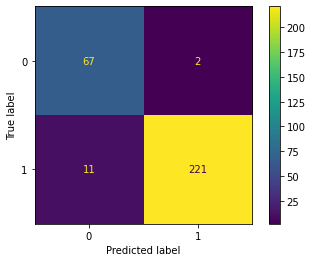

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

TN = 67 — correctly predicted no PPD
FP = 2 — wrongly predicted PPD
FN = 11 — missed real PPD cases
TP = 221 — correctly predicted PPD

In [35]:
import os
print(os.getcwd())

C:\Users\hisan
